In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import PowerTransformer


In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Yeo-Johnson Transformation for Clustering

In [17]:
original_X = X.copy()

In [20]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_numeric_std = pt.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

In [21]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.785036,1,0,1,0,0,1,0.0,0,-1.533345,0.0,0.750782,0.080033,0.343545
1,-0.746998,0,0,0,0,1,0,0.0,1,0.397233,0.0,-1.213660,-1.722060,-1.657833
2,-0.175256,0,1,0,0,0,1,0.0,1,0.830437,1.0,-0.474112,0.735716,0.318631
3,1.371631,0,0,0,0,1,0,0.0,1,0.727938,0.0,-1.992620,-1.291020,-1.835650
4,0.987008,0,0,0,0,1,0,0.0,1,1.144253,0.0,-1.106304,-0.816679,-1.003396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.007949,0,0,1,0,0,1,1.0,0,-1.533345,0.0,-0.158214,-0.822461,-0.611074
135,1.111443,0,0,1,0,0,1,1.0,0,-1.533345,1.0,-0.632361,1.008070,0.474941
136,-0.370651,0,0,1,0,0,1,1.0,1,0.786825,0.0,0.658564,-0.170908,0.133612
137,0.696583,0,0,1,0,0,1,1.0,1,1.554125,1.0,-0.551725,0.574668,0.197985


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

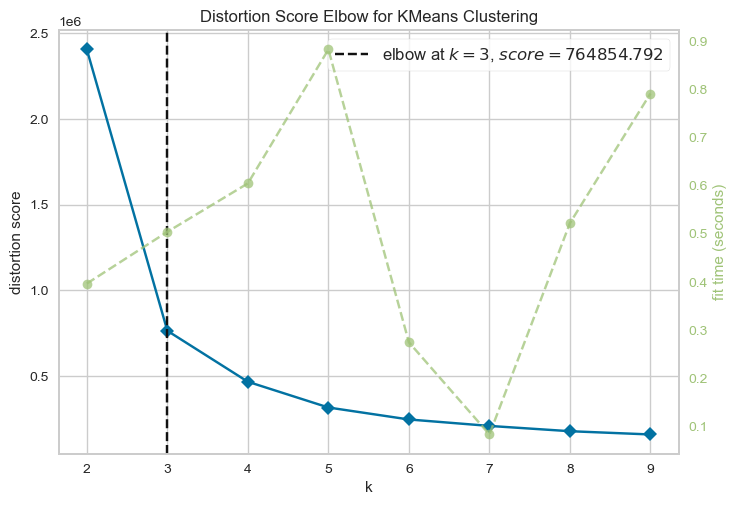

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [22]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [23]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=3)

0
Most correlated column: hpv_related
Correlation coefficient: 0.2460640183505367


1
Most correlated column: age
Correlation coefficient: 1.0072463768115945


2
Most correlated column: MTV
Correlation coefficient: 1.0072463768115945




In [24]:
selected_features

['hpv_related', 'age', 'MTV']

In [25]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Yeo-Johnson Transformation

In [48]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
MAASTRO_new  = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [49]:
X_new

,hpv_related,age,MTV
0,0.0,54.238356,7.934
1,0.0,54.539726,1.656
2,0.0,59.019178,14.502
3,0.0,70.726027,2.440
4,0.0,67.865753,3.668
...,...,...,...
134,1.0,60.435616,3.650
135,1.0,68.794521,18.967
136,1.0,57.498630,6.370
137,1.0,65.684932,12.443


In [50]:
X_new_std

,hpv_related,age,MTV
0,0.0,-0.785036,0.080033
1,0.0,-0.746998,-1.722060
2,0.0,-0.175256,0.735716
3,0.0,1.371631,-1.291020
4,0.0,0.987008,-0.816679
...,...,...,...
134,1.0,0.007949,-0.822461
135,1.0,1.111443,1.008070
136,1.0,-0.370651,-0.170908
137,1.0,0.696583,0.574668


In [51]:
MAASTRO_new

,hpv_related,age,MTV
0,1,55,22.841
1,0,55,5.660
2,0,55,7.791
3,0,61,7.908
4,1,70,15.237
...,...,...,...
94,0,66,6.110
95,0,63,7.182
96,1,63,16.483
97,1,54,9.981


In [52]:
MAASTRO_new_std

,hpv_related,age,MTV
0,1,-0.688798,1.188930
1,0,-0.688798,-0.307894
2,0,-0.688798,0.059450
3,0,0.081262,0.076321
4,1,1.273609,0.786849
...,...,...,...
94,0,0.738387,-0.219083
95,0,0.342484,-0.033134
96,1,0.342484,0.867254
97,1,-0.815082,0.336049


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [53]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:29:29,957] A new study created in memory with name: no-name-ecc1cb0e-0b29-4db1-9534-57ae91c8c5b5


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7446808510638298


[I 2024-04-13 17:29:30,363] A new study created in memory with name: no-name-e59c8320-8599-417f-89e9-540a995655b9


Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:30,341] Trial 0 finished with value: 0.6585165125458967 and parameters: {}. Best is trial 0 with value: 0.6585165125458967.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6585165125458967], datetime_start=datetime.datetime(2024, 4, 13, 17, 29, 29, 994890), datetime_complete=datetime.datetime(2024, 4, 13, 17, 29, 30, 340846), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6585165125458967


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2275238552175
Fold 2 IBS: 0.2108058303052402
Fold 3 IBS: 0.18782196720204689
Fold 4 IBS: 0.23173260660145467
Fold 5 IBS: 0.22342702236572387
[I 2024-04-13 17:29:30,995] Trial 0 finished with value: 0.21626225633839313 and parameters: {}. Best is trial 0 with value: 0.21626225633839313.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21626225633839313], datetime_start=datetime.datetime(2024, 4, 13, 17, 29, 30, 395460), datetime_complete=datetime.datetime(2024, 4, 13, 17, 29, 30, 994885), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21626225633839313


In [54]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.659
train_ibs:  0.216


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.649
IBS score: 0.233


In [58]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [59]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:29:31,523] A new study created in memory with name: no-name-8e3735a2-bc3a-48e8-917f-38257565e662


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4721115537848606
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.5872340425531914


[I 2024-04-13 17:29:31,991] A new study created in memory with name: no-name-d3b0ff09-02ed-4a30-a07e-8d3a4b2b2a25


Fold 4 C-index: 0.5038022813688213
Fold 5 C-index: 0.4742489270386266
[I 2024-04-13 17:29:31,911] Trial 0 finished with value: 0.5253088183134411 and parameters: {}. Best is trial 0 with value: 0.5253088183134411.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5253088183134411], datetime_start=datetime.datetime(2024, 4, 13, 17, 29, 31, 564233), datetime_complete=datetime.datetime(2024, 4, 13, 17, 29, 31, 910903), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5253088183134411


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709986344345
Fold 2 IBS: 0.2320398829421048
Fold 3 IBS: 0.2289818644023179
Fold 4 IBS: 0.24197477278793514
Fold 5 IBS: 0.22939559309038327
[I 2024-04-13 17:29:32,469] Trial 0 finished with value: 0.23592784261723693 and parameters: {}. Best is trial 0 with value: 0.23592784261723693.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784261723693], datetime_start=datetime.datetime(2024, 4, 13, 17, 29, 32, 42746), datetime_complete=datetime.datetime(2024, 4, 13, 17, 29, 32, 469408), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784261723693


In [61]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.525
train_ibs:  0.236


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.638


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [65]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:29:32,877] A new study created in memory with name: no-name-344678c5-e2ff-4a1c-94c5-3c25f2ccbe49


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6692015209125475


[I 2024-04-13 17:29:33,718] A new study created in memory with name: no-name-fc7c75e5-b556-40b5-8c72-9dcd00537b7c


Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:33,705] Trial 0 finished with value: 0.6577413187474471 and parameters: {}. Best is trial 0 with value: 0.6577413187474471.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6577413187474471], datetime_start=datetime.datetime(2024, 4, 13, 17, 29, 33, 45394), datetime_complete=datetime.datetime(2024, 4, 13, 17, 29, 33, 704593), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6577413187474471


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22747812884751975
Fold 2 IBS: 0.2104752739160782
Fold 3 IBS: 0.18851513699258576
Fold 4 IBS: 0.2316837545300665
Fold 5 IBS: 0.22296308381578744
[I 2024-04-13 17:29:34,453] Trial 0 finished with value: 0.21622307562040755 and parameters: {}. Best is trial 0 with value: 0.21622307562040755.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21622307562040755], datetime_start=datetime.datetime(2024, 4, 13, 17, 29, 33, 780779), datetime_complete=datetime.datetime(2024, 4, 13, 17, 29, 34, 452756), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21622307562040755


In [67]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.658
train_ibs:  0.216


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.65


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.232


In [71]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:29:35,360] A new study created in memory with name: no-name-1f950a5b-a5ff-47b8-bd71-164ea234fd15


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:36,096] Trial 0 finished with value: 0.6584259049898739 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6584259049898739.
Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6782945736434108
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:36,733] Trial 1 finished with value: 0.6592010987883234 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.6592010987883234.
Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.5209125475285171
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:37,217] Trial 2 finished with value: 0.6109533904734121 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:51,683] Trial 24 finished with value: 0.6592769688196611 and parameters: {'l1_ratio': 0.6614012819414874}. Best is trial 4 with value: 0.6592769688196611.
Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:52,301] Trial 25 finished with value: 0.6585017750212115 and parameters: {'l1_ratio': 0.891573855041803}. Best is trial 4 with value: 0.6592769688196611.
Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:29:53,156] Trial 26 finished with value: 0.6592769688196611 and parameters: {'l1_ratio': 0.7513232711840059}.

Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:30:07,394] Trial 48 finished with value: 0.6592769688196611 and parameters: {'l1_ratio': 0.7768768486379835}. Best is trial 4 with value: 0.6592769688196611.
Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.5957446808510638
Fold 4 C-index: 0.5019011406844106
Fold 5 C-index: 0.4678111587982833
[I 2024-04-13 17:30:07,680] Trial 49 finished with value: 0.5281320088095787 and parameters: {'l1_ratio': 0.005040986123852953}. Best is trial 4 with value: 0.6592769688196611.
Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.5095057034220533
Fold 5 C-index: 0.4592274678111588
[I 2024-04-13 17:30:07,947] Trial 50 finished with value: 0.5320287490662687 and parameters: {'l1_ratio': 0.08888770157152942}. Best is trial 4 with value: 0

...

Fold 1 IBS: 0.22764513799378544
Fold 2 IBS: 0.21034636367584866
Fold 3 IBS: 0.18847757675783997
Fold 4 IBS: 0.2317141663778446
Fold 5 IBS: 0.22306232236329504
[I 2024-04-13 17:30:39,200] Trial 0 finished with value: 0.21624911343372272 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.21624911343372272.
Fold 1 IBS: 0.22789413405495165
Fold 2 IBS: 0.2101381072487639
Fold 3 IBS: 0.18837360782280307
Fold 4 IBS: 0.23176618763606885
Fold 5 IBS: 0.2231783871804457
[I 2024-04-13 17:30:39,859] Trial 1 finished with value: 0.21627008478860663 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.21624911343372272.
Fold 1 IBS: 0.22791034616064415
Fold 2 IBS: 0.22910469892979343
Fold 3 IBS: 0.1883790201359656
Fold 4 IBS: 0.243550499171797
Fold 5 IBS: 0.22318783583091384
[I 2024-04-13 17:30:40,399] Trial 2 finished with value: 0.2224264800458228 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.2162491134337227

Fold 1 IBS: 0.22752423376795078
Fold 2 IBS: 0.210435637584432
Fold 3 IBS: 0.1884886975032561
Fold 4 IBS: 0.23169287328154545
Fold 5 IBS: 0.2229909735067924
[I 2024-04-13 17:30:55,461] Trial 25 finished with value: 0.21622648312879536 and parameters: {'l1_ratio': 0.9106143729430608}. Best is trial 11 with value: 0.2162231215467479.
Fold 1 IBS: 0.2276133311560382
Fold 2 IBS: 0.21035345428798496
Fold 3 IBS: 0.18845034697344748
Fold 4 IBS: 0.23170868283895402
Fold 5 IBS: 0.2230371161837671
[I 2024-04-13 17:30:56,164] Trial 26 finished with value: 0.21623258628803832 and parameters: {'l1_ratio': 0.7417169602645222}. Best is trial 11 with value: 0.2162231215467479.
Fold 1 IBS: 0.22766786800344344
Fold 2 IBS: 0.21033627914242436
Fold 3 IBS: 0.1884472832771428
Fold 4 IBS: 0.23171915082876504
Fold 5 IBS: 0.22305279160616237
[I 2024-04-13 17:30:56,837] Trial 27 finished with value: 0.21624467457158758 and parameters: {'l1_ratio': 0.6494728799686162}. Best is trial 11 with value: 0.21622312154674

Fold 1 IBS: 0.22754178437491124
Fold 2 IBS: 0.21044142787964035
Fold 3 IBS: 0.18850374168503248
Fold 4 IBS: 0.23169516923824654
Fold 5 IBS: 0.2229861363061558
[I 2024-04-13 17:31:12,067] Trial 50 finished with value: 0.21623365189679727 and parameters: {'l1_ratio': 0.8786447363305766}. Best is trial 40 with value: 0.21622307912553634.
Fold 1 IBS: 0.22750381344628057
Fold 2 IBS: 0.21046615229938087
Fold 3 IBS: 0.18853717675724033
Fold 4 IBS: 0.23168712604309394
Fold 5 IBS: 0.22299646507571047
[I 2024-04-13 17:31:12,695] Trial 51 finished with value: 0.21623814672434122 and parameters: {'l1_ratio': 0.9495136153828908}. Best is trial 40 with value: 0.21622307912553634.
Fold 1 IBS: 0.22750055229216423
Fold 2 IBS: 0.21047074465041327
Fold 3 IBS: 0.18853437768393905
Fold 4 IBS: 0.23168669676091283
Fold 5 IBS: 0.22299729324348624
[I 2024-04-13 17:31:13,346] Trial 52 finished with value: 0.21623793292618312 and parameters: {'l1_ratio': 0.9556391205035538}. Best is trial 40 with value: 0.216223

Fold 5 IBS: 0.2229629560214393
[I 2024-04-13 17:31:33,625] Trial 74 finished with value: 0.21622309144115062 and parameters: {'l1_ratio': 0.9990419168427266}. Best is trial 40 with value: 0.21622307912553634.
Fold 1 IBS: 0.22751764559073342
Fold 2 IBS: 0.21044579417701673
Fold 3 IBS: 0.18848305174627591
Fold 4 IBS: 0.23168903736990218
Fold 5 IBS: 0.22299279914129258
[I 2024-04-13 17:31:34,666] Trial 75 finished with value: 0.21622566560504416 and parameters: {'l1_ratio': 0.9232248440809541}. Best is trial 40 with value: 0.21622307912553634.
Fold 1 IBS: 0.2274944116707591
Fold 2 IBS: 0.21047940169024507
Fold 3 IBS: 0.1885291076972077
Fold 4 IBS: 0.2316858893889007
Fold 5 IBS: 0.2229988556335234
[I 2024-04-13 17:31:35,716] Trial 76 finished with value: 0.21623753321612718 and parameters: {'l1_ratio': 0.9673906281038791}. Best is trial 40 with value: 0.21622307912553634.
Fold 1 IBS: 0.22753079273318516
Fold 2 IBS: 0.21042554366079944
Fold 3 IBS: 0.1884943190678641
Fold 4 IBS: 0.2316937301

Fold 1 IBS: 0.22749588310841598
Fold 2 IBS: 0.21047732608855974
Fold 3 IBS: 0.18853037044430285
Fold 4 IBS: 0.23168608274125865
Fold 5 IBS: 0.2229984808925815
[I 2024-04-13 17:31:55,719] Trial 99 finished with value: 0.21623762865502374 and parameters: {'l1_ratio': 0.964548404109892}. Best is trial 40 with value: 0.21622307912553634.


* Best trial for IBS: 
 FrozenTrial(number=40, state=TrialState.COMPLETE, values=[0.21622307912553634], datetime_start=datetime.datetime(2024, 4, 13, 17, 31, 4, 940893), datetime_complete=datetime.datetime(2024, 4, 13, 17, 31, 5, 530111), params={'l1_ratio': 0.9997874437591321}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=40, value=None)


* Best Score for IBS: 
 0.21622307912553634


In [73]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.659
train_ibs:  0.216


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.7194970228885845)

test_cindex : 0.65


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.9997874437591321)

test_ibs:  0.232


In [77]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [78]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:31:56,302] A new study created in memory with name: no-name-0fa27705-7976-4565-a6c3-09b69a2e3112


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6434108527131783
Fold 3 C-index: 0.6914893617021277
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6351931330472103
[I 2024-04-13 17:32:03,758] Trial 0 finished with value: 0.650749919397825 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.650749919397825.
Fold 1 C-index: 0.5239043824701195
Fold 2 C-index: 0.6356589147286822
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6349809885931559
Fold 5 C-index: 0.6394849785407726
[I 2024-04-13 17:32:08,272] Trial 1 finished with value: 0.6238271294622907 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 1 C-index: 0.5099601593625498
Fold 2 C-index: 0.6782945736434108
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6996197718631179
Fold 5 C-index: 0.6180257510729614
[I 2024-04-13 17:33:28,703] Trial 16 finished with value: 0.6382013277841526 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 497, 'oob_score': True, 'max_samples': 0.44827686549014745, 'max_features': None, 'min_weight_fraction_leaf': 0.11772637407684824, 'warm_start': True}. Best is trial 14 with value: 0.6948456638225776.
Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.6724806201550387
Fold 3 C-index: 0.7106382978723405
Fold 4 C-index: 0.7319391634980988
Fold 5 C-index: 0.6351931330472103
[I 2024-04-13 17:33:33,897] Trial 17 finished with value: 0.6699705616396373 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 4, 'min_samples_leaf': 16, 'max_depth': 6, 'n_estimators': 384, 'oob_score': True, 'max_samples': 0.40997938514589805

Fold 1 C-index: 0.6254980079681275
Fold 2 C-index: 0.6957364341085271
Fold 3 C-index: 0.7553191489361702
Fold 4 C-index: 0.7395437262357415
Fold 5 C-index: 0.6373390557939914
[I 2024-04-13 17:34:27,457] Trial 31 finished with value: 0.6906872746085116 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 7, 'min_samples_leaf': 17, 'max_depth': 13, 'n_estimators': 145, 'oob_score': True, 'max_samples': 0.7287853010513338, 'max_features': None, 'min_weight_fraction_leaf': 0.2277438810173386, 'warm_start': True}. Best is trial 29 with value: 0.6949808338464686.
Fold 1 C-index: 0.6235059760956175
Fold 2 C-index: 0.6918604651162791
Fold 3 C-index: 0.7638297872340426
Fold 4 C-index: 0.7395437262357415
Fold 5 C-index: 0.6373390557939914
[I 2024-04-13 17:34:30,733] Trial 32 finished with value: 0.6912158020951344 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 7, 'min_samples_leaf': 17, 'max_depth': 13, 'n_estimators': 140, 'oob_score': True, 'max_samples': 0.7315868527553735

...

Fold 1 IBS: 0.24140546914010683
Fold 2 IBS: 0.21980453585793608
Fold 3 IBS: 0.21754012012686982
Fold 4 IBS: 0.2332315174825289
Fold 5 IBS: 0.21439680579834855
[I 2024-04-13 17:41:01,902] Trial 32 finished with value: 0.22527568968115802 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 258, 'oob_score': False, 'max_samples': 0.5048409346506281, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1354557288037115}. Best is trial 0 with value: 0.22269667986557368.
Fold 1 IBS: 0.23695333069714317
Fold 2 IBS: 0.22257591675676897
Fold 3 IBS: 0.2225111927091977
Fold 4 IBS: 0.22699356819772343
Fold 5 IBS: 0.21848001036224124
[I 2024-04-13 17:41:02,726] Trial 33 finished with value: 0.2255028037446149 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 5, 'n_estimators': 19, 'oob_score': False, 'max_samples': 0.7088178154422675, 'max_features': 'auto', 'min_weight_fraction_leaf':

Fold 1 IBS: 0.24616718184581154
Fold 2 IBS: 0.232234675158183
Fold 3 IBS: 0.22956667040912188
Fold 4 IBS: 0.24150913004294472
Fold 5 IBS: 0.23022764898067985
[I 2024-04-13 17:43:30,687] Trial 48 finished with value: 0.2359410612873482 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 428, 'oob_score': True, 'max_samples': 0.4654393831126186, 'max_features': None, 'min_weight_fraction_leaf': 0.26782620394582757}. Best is trial 0 with value: 0.22269667986557368.
Fold 1 IBS: 0.24644604385951377
Fold 2 IBS: 0.2322583356138665
Fold 3 IBS: 0.22956721409485442
Fold 4 IBS: 0.24151691492442612
Fold 5 IBS: 0.23028775595671364
[I 2024-04-13 17:43:46,101] Trial 49 finished with value: 0.23601525288987485 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 473, 'oob_score': True, 'max_samples': 0.39635357610774735, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.24297350911063278
Fold 2 IBS: 0.22707450431093143
Fold 3 IBS: 0.21805937465364011
Fold 4 IBS: 0.23456162776998501
Fold 5 IBS: 0.21833381897552157
[I 2024-04-13 17:47:12,643] Trial 64 finished with value: 0.22820056696414218 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 12, 'min_samples_leaf': 7, 'max_depth': 6, 'n_estimators': 323, 'oob_score': True, 'max_samples': 0.4779553029819325, 'max_features': None, 'min_weight_fraction_leaf': 0.19215691057479128}. Best is trial 0 with value: 0.22269667986557368.
Fold 1 IBS: 0.24220139795084064
Fold 2 IBS: 0.22400339427540056
Fold 3 IBS: 0.21734995518484812
Fold 4 IBS: 0.23344654128126846
Fold 5 IBS: 0.21791328556150225
[I 2024-04-13 17:47:28,170] Trial 65 finished with value: 0.226982914850772 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 6, 'max_depth': 13, 'n_estimators': 410, 'oob_score': True, 'max_samples': 0.5235519372206235, 'max_features': 'log2', 'min_weight_fraction_lea

Fold 1 IBS: 0.2554118768227915
Fold 2 IBS: 0.22961951344701795
Fold 3 IBS: 0.22326873513311893
Fold 4 IBS: 0.24168158419045419
Fold 5 IBS: 0.22809927029140908
[I 2024-04-13 17:49:44,390] Trial 80 finished with value: 0.23561619597695832 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 14, 'min_samples_leaf': 7, 'max_depth': 11, 'n_estimators': 312, 'oob_score': False, 'max_samples': 0.44980862326544857, 'max_features': None, 'min_weight_fraction_leaf': 0.20599406352159094}. Best is trial 0 with value: 0.22269667986557368.
Fold 1 IBS: 0.23467312210571464
Fold 2 IBS: 0.22608202578282327
Fold 3 IBS: 0.20950597480461935
Fold 4 IBS: 0.22948911396198374
Fold 5 IBS: 0.21364569982857012
[I 2024-04-13 17:49:52,288] Trial 81 finished with value: 0.2226791872967422 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_depth': 5, 'n_estimators': 287, 'oob_score': False, 'max_samples': 0.5349040396724107, 'max_features': None, 'min_weight_fraction_lea

Fold 1 IBS: 0.24230299097814317
Fold 2 IBS: 0.21748131340138224
Fold 3 IBS: 0.21915991086737482
Fold 4 IBS: 0.23169337227990594
Fold 5 IBS: 0.21452911654960788
[I 2024-04-13 17:51:50,084] Trial 96 finished with value: 0.22503334081528284 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 7, 'max_depth': 6, 'n_estimators': 373, 'oob_score': False, 'max_samples': 0.5653915393530762, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.13062517881374777}. Best is trial 81 with value: 0.2226791872967422.
Fold 1 IBS: 0.23791980939063917
Fold 2 IBS: 0.23138674401232823
Fold 3 IBS: 0.21994793296191084
Fold 4 IBS: 0.23575813027963116
Fold 5 IBS: 0.21138023855136057
[I 2024-04-13 17:51:58,160] Trial 97 finished with value: 0.22727857103917398 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 6, 'min_samples_leaf': 5, 'max_depth': 10, 'n_estimators': 228, 'oob_score': False, 'max_samples': 0.618104199397526, 'max_features': None, 'min_weight_fraction_le

In [79]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [80]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.787
train_ibs:  0.223


#### Test

In [81]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [82]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=19, max_features=None, max_leaf_nodes=13,
                     max_samples=0.900914890356406, min_samples_leaf=2,
                     min_samples_split=10,
                     min_weight_fraction_leaf=0.003478792374268588,
                     n_estimators=63, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.561


RandomSurvivalForest(max_depth=5, max_features=None, max_leaf_nodes=8,
                     max_samples=0.5349040396724107, min_samples_leaf=5,
                     min_samples_split=15,
                     min_weight_fraction_leaf=0.17767776419652503,
                     n_estimators=287, random_state=123)

test_ibs:  0.22


In [83]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [84]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:52:17,937] A new study created in memory with name: no-name-540e505d-bf5a-40c0-9509-8cf724dac833


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6195219123505976
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7617021276595745
Fold 4 C-index: 0.7566539923954373
Fold 5 C-index: 0.6223175965665236
[I 2024-04-13 17:52:20,331] Trial 0 finished with value: 0.6915740095153569 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6915740095153569.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:52:26,888] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 3 C-index: 0.7659574468085106
Fold 4 C-index: 0.7490494296577946
Fold 5 C-index: 0.6266094420600858
[I 2024-04-13 17:53:42,853] Trial 15 finished with value: 0.6902553802005376 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 362, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.9163782618183121, 'min_weight_fraction_leaf': 0.07436726243220565}. Best is trial 14 with value: 0.6918125222364708.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:53:45,181] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 6, 'min_samples_leaf': 4, 'max_depth': 16, 'n_estimators': 277, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.12362405012814498, 'min_weight_fraction_leaf': 0.35612645124522524}. Best is trial 14 with value: 0.6918125222364708.
Fold 1 C-index:

Fold 1 C-index: 0.6195219123505976
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.7642585551330798
Fold 5 C-index: 0.630901287553648
[I 2024-04-13 17:54:52,498] Trial 30 finished with value: 0.6916350150351741 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 10, 'n_estimators': 331, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9391734763657503, 'min_weight_fraction_leaf': 0.0953753947802839}. Best is trial 14 with value: 0.6918125222364708.
Fold 1 C-index: 0.6254980079681275
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.7680608365019012
Fold 5 C-index: 0.6394849785407726
[I 2024-04-13 17:54:56,151] Trial 31 finished with value: 0.6927542371405077 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 10, 'n_estimators': 328, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.23396709710695887
Fold 2 IBS: 0.2246299240942738
Fold 3 IBS: 0.2162700506473148
Fold 4 IBS: 0.22861886203800613
Fold 5 IBS: 0.21842292501432312
[I 2024-04-13 18:08:40,135] Trial 30 finished with value: 0.22438177178017532 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 13, 'min_samples_leaf': 13, 'max_depth': 15, 'n_estimators': 400, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8289563029910445, 'min_weight_fraction_leaf': 0.27072680816988576}. Best is trial 17 with value: 0.21673694693370252.
Fold 1 IBS: 0.22290785150709583
Fold 2 IBS: 0.23050335198050156
Fold 3 IBS: 0.2067913711021412
Fold 4 IBS: 0.21687646272874142
Fold 5 IBS: 0.21247342839230066
[I 2024-04-13 18:09:01,759] Trial 31 finished with value: 0.21791049314215613 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 20, 'n_estimators': 451, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 

Fold 1 IBS: 0.2258637664528759
Fold 2 IBS: 0.22524432542361159
Fold 3 IBS: 0.21255626574974384
Fold 4 IBS: 0.2221578010346085
Fold 5 IBS: 0.21233085607109126
[I 2024-04-13 18:13:04,811] Trial 45 finished with value: 0.21963060294638623 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 7, 'min_samples_leaf': 20, 'max_depth': 18, 'n_estimators': 447, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.5688651141103851, 'min_weight_fraction_leaf': 0.16638340518787215}. Best is trial 17 with value: 0.21673694693370252.
Fold 1 IBS: 0.2334834834094353
Fold 2 IBS: 0.22548894256731922
Fold 3 IBS: 0.22078256063420912
Fold 4 IBS: 0.23043925650868347
Fold 5 IBS: 0.21562620623735662
[I 2024-04-13 18:13:18,699] Trial 46 finished with value: 0.22516408987140074 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 15, 'n_estimators': 481, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.

Fold 1 IBS: 0.23396070826549867
Fold 2 IBS: 0.22527177309804092
Fold 3 IBS: 0.2195184071279017
Fold 4 IBS: 0.22876920735913928
Fold 5 IBS: 0.2147214576843852
[I 2024-04-13 18:16:33,610] Trial 60 finished with value: 0.22444831070699314 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 9, 'min_samples_leaf': 19, 'max_depth': 18, 'n_estimators': 461, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.6391411801898657, 'min_weight_fraction_leaf': 0.28078021997933933}. Best is trial 17 with value: 0.21673694693370252.
Fold 1 IBS: 0.2225131481763412
Fold 2 IBS: 0.23205440670509794
Fold 3 IBS: 0.2065981047288756
Fold 4 IBS: 0.21656618057841712
Fold 5 IBS: 0.21259055204600386
[I 2024-04-13 18:16:48,814] Trial 61 finished with value: 0.21806447844694715 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 18, 'max_depth': 20, 'n_estimators': 412, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.758

Fold 1 IBS: 0.22927048158042532
Fold 2 IBS: 0.2246804377447384
Fold 3 IBS: 0.21522129475583268
Fold 4 IBS: 0.22445469677599206
Fold 5 IBS: 0.21368304723991122
[I 2024-04-13 18:20:51,835] Trial 75 finished with value: 0.22146199161937993 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 8, 'min_samples_leaf': 20, 'max_depth': 3, 'n_estimators': 499, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7121351606310725, 'min_weight_fraction_leaf': 0.3059470800011994}. Best is trial 17 with value: 0.21673694693370252.
Fold 1 IBS: 0.24634890787823616
Fold 2 IBS: 0.2321521892434059
Fold 3 IBS: 0.22958123729603097
Fold 4 IBS: 0.2415101153686271
Fold 5 IBS: 0.23025107079313076
[I 2024-04-13 18:21:08,515] Trial 76 finished with value: 0.23596870411588616 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 16, 'min_samples_leaf': 18, 'max_depth': 10, 'n_estimators': 377, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8

Fold 1 IBS: 0.2331915171683448
Fold 2 IBS: 0.22451525441341771
Fold 3 IBS: 0.21592110835435316
Fold 4 IBS: 0.22757166095283987
Fold 5 IBS: 0.21783491437394067
[I 2024-04-13 18:24:52,581] Trial 90 finished with value: 0.22380689105257928 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 7, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 419, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9984342141553619, 'min_weight_fraction_leaf': 0.2631211336047499}. Best is trial 17 with value: 0.21673694693370252.
Fold 1 IBS: 0.22386923938845832
Fold 2 IBS: 0.2273609912849262
Fold 3 IBS: 0.20886798652274602
Fold 4 IBS: 0.21914976961318572
Fold 5 IBS: 0.2121889035089326
[I 2024-04-13 18:25:14,271] Trial 91 finished with value: 0.21828737806364976 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 9, 'min_samples_leaf': 20, 'max_depth': 14, 'n_estimators': 485, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7229

In [85]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [86]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.76
train_ibs:  0.214


#### Test

In [87]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [88]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=17, max_features=None, max_leaf_nodes=20,
                   max_samples=0.9981670362573866, min_samples_leaf=2,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.013033045137327982,
                   n_estimators=234, random_state=123, warm_start=True)

C-index score: 0.582


ExtraSurvivalTrees(max_depth=19, max_features=None, max_leaf_nodes=10,
                   max_samples=0.8627535569319936, min_samples_leaf=2,
                   min_samples_split=9,
                   min_weight_fraction_leaf=0.023565939783552786,
                   n_estimators=310, oob_score=True, random_state=123)

IBS: 0.229


In [89]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [90]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 18:27:16,183] A new study created in memory with name: no-name-6a06b059-9104-480d-91f1-5345bfb4d106


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:28:12,373] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:28:44,836] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:44:49,935] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6275379993860082.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:46:45,844] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-13 19:07:35,249] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.6275379993860082.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 19:10:00,163] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:37:08,151] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5628832155203615, 'learning_rate': 0.05692286295358468, 'dropout_rate': 0.683156188511181, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 9.07255185322531, 'min_weight_fraction_leaf': 0.21518215373385774, 'max_features': None, 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.8420815814864784, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 10}. Best is trial 9 with value: 0.23564947762218713.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:37:18,218] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9436582561003044, 'learning_rate': 0.07482848784358435, 'dropout_rate': 0.85957479691200

Fold 5 IBS: 0.22738219047571917
[I 2024-04-13 21:48:16,931] Trial 55 finished with value: 0.23379818491718424 and parameters: {'subsample': 0.5887322566034815, 'learning_rate': 0.03248154248395621, 'dropout_rate': 0.20419816136861105, 'n_estimators': 357, 'criterion': 'friedman_mse', 'ccp_alpha': 0.036799960796019306, 'min_weight_fraction_leaf': 0.30861253825639257, 'max_features': None, 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4978860670989092, 'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 13}. Best is trial 53 with value: 0.2327935908039604.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:49:26,907] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.48190513355031883, 'learning_rate': 0.030884976740502446, 'dropout_rate': 0.19804020971050568, 'n_estimators': 358

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:19:46,311] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.438028248164699, 'learning_rate': 0.03766085593505888, 'dropout_rate': 0.1895894544757071, 'n_estimators': 386, 'criterion': 'friedman_mse', 'ccp_alpha': 1.083648192803729, 'min_weight_fraction_leaf': 0.37503875397028397, 'max_features': None, 'min_impurity_decrease': 0.0014046872430471702, 'validation_fraction': 0.3956139648140855, 'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 8, 'max_depth': 14}. Best is trial 53 with value: 0.2327935908039604.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:20:53,208] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsam

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.2419747714592711
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 23:07:34,912] Trial 78 finished with value: 0.2359278435123307 and parameters: {'subsample': 0.3686502019766869, 'learning_rate': 0.048491167717482735, 'dropout_rate': 0.19072333149111204, 'n_estimators': 255, 'criterion': 'friedman_mse', 'ccp_alpha': 0.2892263106266832, 'min_weight_fraction_leaf': 0.4454723403945225, 'max_features': None, 'min_impurity_decrease': 0.00038081001844946015, 'validation_fraction': 0.44682774336424097, 'min_samples_split': 2, 'max_leaf_nodes': 3, 'min_samples_leaf': 9, 'max_depth': 11}. Best is trial 53 with value: 0.2327935908039604.
Fold 1 IBS: 0.24655773703921272
Fold 2 IBS: 0.23030800461100423
Fold 3 IBS: 0.22745159612247443
Fold 4 IBS: 0.24053682229789142
Fold 5 IBS: 0.22775241962797446
[I 2024-04-13 23:31:54,655] Trial 79 finished with value: 0.23452131593971143 and parameters: {'subsample': 0.32859077945582116, '

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 23:40:19,800] Trial 89 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7367507157271612, 'learning_rate': 0.02358908918298416, 'dropout_rate': 0.1377356332456206, 'n_estimators': 408, 'criterion': 'friedman_mse', 'ccp_alpha': 0.7722725099497573, 'min_weight_fraction_leaf': 0.31347189210993603, 'max_features': None, 'min_impurity_decrease': 0.01806689386438656, 'validation_fraction': 0.37435049035412227, 'min_samples_split': 4, 'max_leaf_nodes': 6, 'min_samples_leaf': 10, 'max_depth': 11}. Best is trial 87 with value: 0.2321269138686866.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 23:41:13,397] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7033043773993295, 'learning_rate': 0.02964178058869890

In [91]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [92]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.646
train_ibs:  0.232


#### Test

In [93]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [94]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03680304263373871,
                                 dropout_rate=0.8859792395781099,
                                 learning_rate=0.07808142247997509,
                                 max_depth=15, max_features='sqrt',
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=0.008146563872249941,
                                 min_samples_leaf=19, min_samples_split=11,
                                 min_weight_fraction_leaf=0.15390921956023235,
                                 n_estimators=117, random_state=123,
                                 subsample=0.6260529149480705,
                                 validation_fraction=0.4043604570150481)

C-index score: 0.65


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004367037932470236,
                                 dropout_rate=0.14349478026594298,
                                 learning_rate=0.05123968597919707,
                                 max_depth=12, max_leaf_nodes=2,
                                 min_impurity_decrease=0.000409992930132572,
                                 min_samples_leaf=14, min_samples_split=6,
                                 min_weight_fraction_leaf=0.29453241407710784,
                                 n_estimators=321, random_state=123,
                                 subsample=0.6473842724309151,
                                 validation_fraction=0.3247291893167919)

IBS: 0.224


In [95]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [96]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)

                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:58:59,233] A new study created in memory with name: no-name-5893ca41-1545-4247-b386-591b8da17cbf


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6553191489361702
Fold 4 C-index: 0.5133079847908745
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 23:59:06,022] Trial 0 finished with value: 0.5911253575806732 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5911253575806732.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6553191489361702
Fold 4 C-index: 0.5133079847908745
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 23:59:50,915] Trial 1 finished with value: 0.5911253575806732 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5911253575806732.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6553191489361702
Fold 4 

Fold 1 C-index: 0.6135458167330677
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.6680851063829787
Fold 4 C-index: 0.5893536121673004
Fold 5 C-index: 0.5836909871244635
[I 2024-04-14 00:04:52,966] Trial 19 finished with value: 0.6242684378148955 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 11 with value: 0.6272124770718392.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.6595744680851063
Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.5622317596566524
[I 2024-04-14 00:05:18,068] Trial 20 finished with value: 0.6143994703424579 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 11 with value: 0.6272124770718392.
Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.6680851063829787

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.6553191489361702
Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.5579399141630901
[I 2024-04-14 00:10:08,464] Trial 38 finished with value: 0.6119148436155086 and parameters: {'subsample': 0.3287521118750758, 'dropout_rate': 0.13643252115687343, 'n_estimators': 392, 'learning_rate': 0.07288612365177065}. Best is trial 24 with value: 0.6277804346459515.
Fold 1 C-index: 0.6135458167330677
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.6510638297872341
Fold 4 C-index: 0.5855513307984791
Fold 5 C-index: 0.5665236051502146
[I 2024-04-14 00:10:12,871] Trial 39 finished with value: 0.6158950560286828 and parameters: {'subsample': 0.195910747923496, 'dropout_rate': 0.29848665859072016, 'n_estimators': 145, 'learning_rate': 0.09286196768256472}. Best is trial 24 with value: 0.6277804346459515.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.6553191489361702


...

Fold 2 IBS: 0.26567464017371795
Fold 3 IBS: 0.22043696581720548
Fold 4 IBS: 0.29719732860076087
Fold 5 IBS: 0.2339410425021079
[I 2024-04-14 00:46:00,084] Trial 19 finished with value: 0.25531075869001835 and parameters: {'subsample': 0.23213625139224725, 'dropout_rate': 0.2379003838874303, 'n_estimators': 341, 'learning_rate': 0.04061015936667263}. Best is trial 15 with value: 0.22562356714272885.
Fold 1 IBS: 0.2475429459041505
Fold 2 IBS: 0.26505994908786973
Fold 3 IBS: 0.2187743582212345
Fold 4 IBS: 0.3056784973502043
Fold 5 IBS: 0.22908759510623794
[I 2024-04-14 00:46:03,963] Trial 20 finished with value: 0.2532286691339394 and parameters: {'subsample': 0.3923190305501453, 'dropout_rate': 0.30866564063362517, 'n_estimators': 150, 'learning_rate': 0.0817175642960023}. Best is trial 15 with value: 0.22562356714272885.
Fold 1 IBS: 0.23368071863845927
Fold 2 IBS: 0.22421074214665712
Fold 3 IBS: 0.2162892674119637
Fold 4 IBS: 0.2415901220470357
Fold 5 IBS: 0.21838592581519933
[I 2024-04

Fold 2 IBS: 0.22245299692012097
Fold 3 IBS: 0.20806305397227667
Fold 4 IBS: 0.2516192747406965
Fold 5 IBS: 0.2170060793269506
[I 2024-04-14 00:47:14,993] Trial 38 finished with value: 0.22616097588437284 and parameters: {'subsample': 0.16691532803713965, 'dropout_rate': 0.18816503285796835, 'n_estimators': 174, 'learning_rate': 0.029948791397965753}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.23290385104674877
Fold 2 IBS: 0.22293117569377693
Fold 3 IBS: 0.21093917524754524
Fold 4 IBS: 0.24659389236486914
Fold 5 IBS: 0.21682764185467598
[I 2024-04-14 00:47:23,535] Trial 39 finished with value: 0.22603914724152321 and parameters: {'subsample': 0.2754457950066489, 'dropout_rate': 0.26358168846241053, 'n_estimators': 241, 'learning_rate': 0.013931445007643331}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.24350032906475186
Fold 2 IBS: 0.22939933526526926
Fold 3 IBS: 0.22510640836414844
Fold 4 IBS: 0.2422413180224908
Fold 5 IBS: 0.22627723652108656
[I

Fold 1 IBS: 0.22997367866310667
Fold 2 IBS: 0.22426394742739594
Fold 3 IBS: 0.20752233438245865
Fold 4 IBS: 0.25436987897482727
Fold 5 IBS: 0.21557009090499824
[I 2024-04-14 00:50:18,618] Trial 57 finished with value: 0.22633998607055736 and parameters: {'subsample': 0.22915143127792356, 'dropout_rate': 0.1256570317106392, 'n_estimators': 225, 'learning_rate': 0.022393215460972685}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.23533758577761793
Fold 2 IBS: 0.22521457423517707
Fold 3 IBS: 0.21686890811567797
Fold 4 IBS: 0.24590477753921539
Fold 5 IBS: 0.21918068473269767
[I 2024-04-14 00:50:29,736] Trial 58 finished with value: 0.22850130608007718 and parameters: {'subsample': 0.3585294847321296, 'dropout_rate': 0.5889976706611455, 'n_estimators': 303, 'learning_rate': 0.00584393503693551}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.23406099511469952
Fold 2 IBS: 0.2329415561868515
Fold 3 IBS: 0.2058287343596395
Fold 4 IBS: 0.2625155052225436
Fold 

Fold 1 IBS: 0.23561247766613105
Fold 2 IBS: 0.22843352021492594
Fold 3 IBS: 0.20614545480276647
Fold 4 IBS: 0.2510165334601341
Fold 5 IBS: 0.21624484882808326
[I 2024-04-14 00:52:57,604] Trial 76 finished with value: 0.2274905669944082 and parameters: {'subsample': 0.2216203259172627, 'dropout_rate': 0.2549767432342452, 'n_estimators': 152, 'learning_rate': 0.04268542040928821}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.2471290718441325
Fold 2 IBS: 0.24302158680088007
Fold 3 IBS: 0.2150767078997177
Fold 4 IBS: 0.27449173107542735
Fold 5 IBS: 0.22502156074061694
[I 2024-04-14 00:53:05,522] Trial 77 finished with value: 0.2409481316721549 and parameters: {'subsample': 0.1629372600879722, 'dropout_rate': 0.15206165725377543, 'n_estimators': 222, 'learning_rate': 0.05192747336419614}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.23123702260205894
Fold 2 IBS: 0.2215779036188455
Fold 3 IBS: 0.20681947150254934
Fold 4 IBS: 0.25025201633107413
Fold 5 IB

Fold 1 IBS: 0.23154586408047464
Fold 2 IBS: 0.22234757454961057
Fold 3 IBS: 0.2094484779627054
Fold 4 IBS: 0.24765843542845628
Fold 5 IBS: 0.21717811417536242
[I 2024-04-14 00:54:25,343] Trial 95 finished with value: 0.22563569323932184 and parameters: {'subsample': 0.27282927846016813, 'dropout_rate': 0.16517508657098032, 'n_estimators': 141, 'learning_rate': 0.025259080193371426}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.23270717233092814
Fold 2 IBS: 0.2244679544098143
Fold 3 IBS: 0.2148780214753533
Fold 4 IBS: 0.24314144417464248
Fold 5 IBS: 0.21980338002716834
[I 2024-04-14 00:54:27,000] Trial 96 finished with value: 0.22699959448358129 and parameters: {'subsample': 0.3535405037686001, 'dropout_rate': 0.11549925471445563, 'n_estimators': 73, 'learning_rate': 0.030702383182510118}. Best is trial 30 with value: 0.22328822811242674.
Fold 1 IBS: 0.23766369385024128
Fold 2 IBS: 0.22465934526683776
Fold 3 IBS: 0.21790687565948658
Fold 4 IBS: 0.24344388997728256
Fol

In [97]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [98]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.629
train_ibs:  0.223


#### Test

In [99]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [100]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.13146619174832977,
                                              learning_rate=0.0862243918189567,
                                              n_estimators=347,
                                              random_state=123,
                                              subsample=0.10995725056704807)

C-index score: 0.675


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10299054481491775,
                                              learning_rate=0.03453320662016267,
                                              n_estimators=135,
                                              random_state=123,
                                              subsample=0.2550251491363914)

IBS: 0.216


In [101]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [102]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.787,1.0
ExtraSurvivalTrees,0.760,2.0
CoxPH,0.659,3.5
CoxElastic,0.659,3.5
CoxLasso,0.658,5.0
GradientBoosting,0.646,6.0
ComponentwiseGradientBoosting,0.629,7.0
CoxRidge,0.525,8.0


In [103]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.214,1.0
CoxPH,0.216,3.0
CoxLasso,0.216,3.0
CoxElastic,0.216,3.0
Randomsurvivalforest,0.223,5.5
ComponentwiseGradientBoosting,0.223,5.5
GradientBoosting,0.232,7.0
CoxRidge,0.236,8.0


In [104]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.675,1.0
CoxLasso,0.650,3.0
CoxElastic,0.650,3.0
GradientBoosting,0.650,3.0
CoxPH,0.649,5.0
CoxRidge,0.638,6.0
ExtraSurvivalTrees,0.582,7.0
Randomsurvivalforest,0.561,8.0


In [105]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.216,1.0
Randomsurvivalforest,0.220,2.0
GradientBoosting,0.224,3.0
CoxRidge,0.229,4.5
ExtraSurvivalTrees,0.229,4.5
CoxLasso,0.232,6.5
CoxElastic,0.232,6.5
CoxPH,0.233,8.0


In [107]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/yeojohnson/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_yeojohnson_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [108]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
